In [1]:
import pandas as pd
import joblib

from tools import evaluate_model

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

In [2]:
X_train = pd.read_pickle(r"..\data\processed\X_train_clean.pkl")
X_test = pd.read_pickle(r"..\data\processed\X_test_clean.pkl")
y_train = pd.read_pickle(r"..\data\processed\y_train.pkl")
y_test = pd.read_pickle(r"..\data\processed\y_test.pkl")

In [3]:
param_grid = {
    'n_estimators': [300, 400, 500, 600],
    'max_depth':[1, 2, 3],
    'min_samples_split': [2, 3, 4],
    'class_weight': [None, 'balanced'],
}

gridSearch = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    scoring='recall',
    refit=True,
    cv=5,
    n_jobs=-1
)

gridSearch.fit(X_train, y_train)

gridSearch.best_params_

{'class_weight': 'balanced',
 'max_depth': 2,
 'min_samples_split': 2,
 'n_estimators': 400}

In [4]:
model = gridSearch.best_estimator_

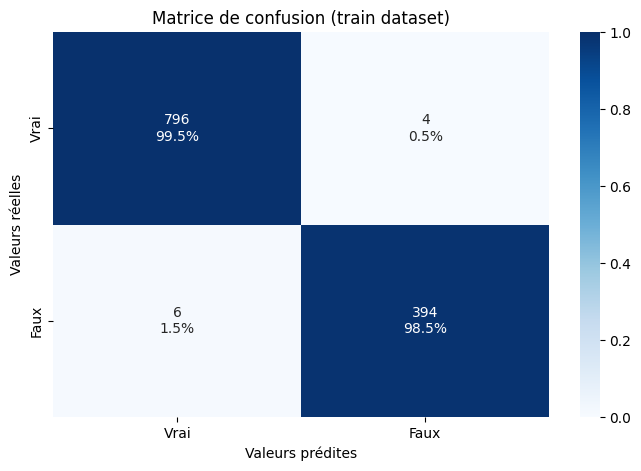

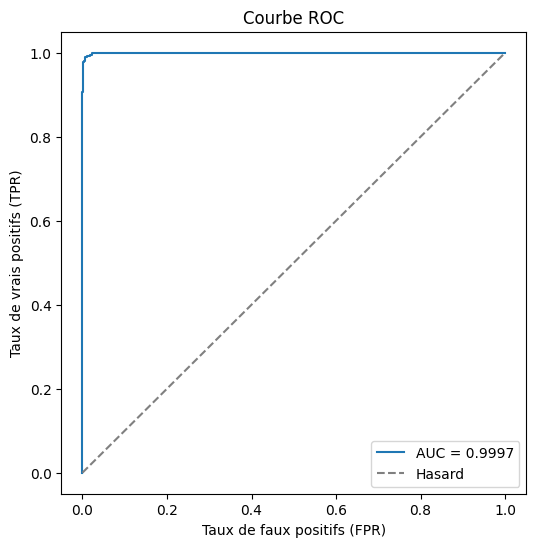

recall_score : 98.50%


In [5]:
_ = evaluate_model(model, X_train, y_train, ["Vrai", "Faux"], "recall", "Matrice de confusion (train dataset)")

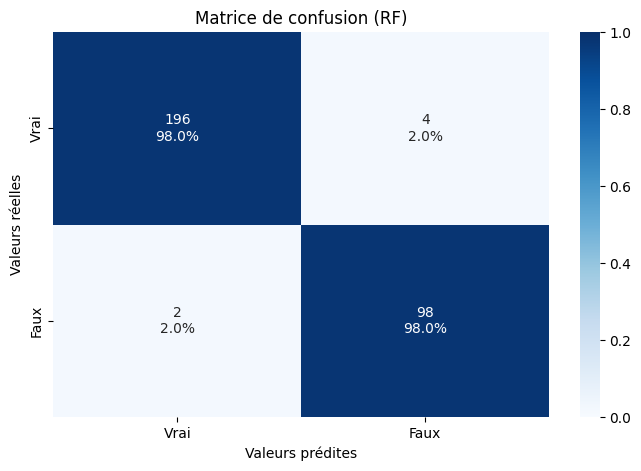

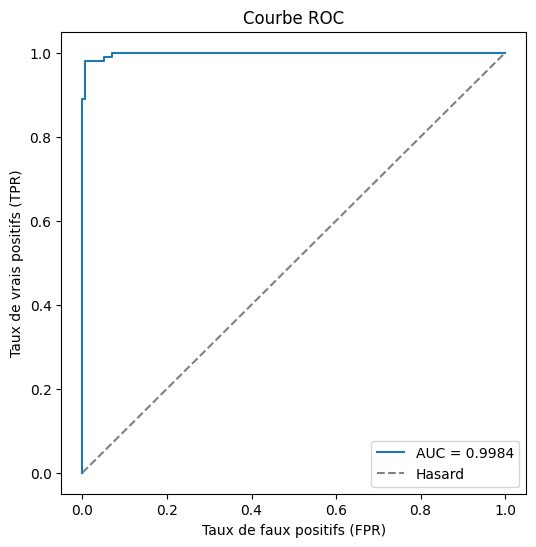

recall_score : 98.00%


In [6]:
_ = evaluate_model(model, X_test, y_test, ["Vrai", "Faux"], "recall", "Matrice de confusion (RF)")

In [7]:
joblib.dump(gridSearch.best_estimator_, r"..\models\RF.pkl")

['..\\models\\RF.pkl']